In [ ]:
import sqlite3
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

In [9]:
# movies_df = pd.read_csv('./data\\raw\\archive\\movies.csv')
# ratings_df = pd.read_csv('./data\\raw\\archive\\ratings.csv')

# print('Movies DataFrame head:')
# display(movies_df.head())

# print('\nRatings DataFrame head:')
# display(ratings_df.head())

# conn = sqlite3.connect('./data\\raw\\movies.db')

# movies_df.to_sql('movies', conn, if_exists='replace', index=False)
# ratings_df.to_sql('ratings', conn, if_exists='replace', index=False)

# print('DataFrames successfully loaded into movies.db')

### Data Extraction

In [11]:
conn = sqlite3.connect("../data/raw/movies.db")

query_movie = """
SELECT *
FROM movies
"""
movies_df = pd.read_sql_query(query_movie, conn)

query_rating = """
SELECT *
FROM ratings
"""

ratings_df = pd.read_sql_query(query_rating, conn)

In [12]:
movies_df.columns = movies_df.columns.str.lower()
ratings_df.columns = ratings_df.columns.str.lower()

In [13]:
print(movies_df.dtypes)
print(ratings_df.dtypes)

movieid    int64
title        str
genres       str
dtype: object
userid         int64
movieid        int64
rating       float64
timestamp      int64
dtype: object


In [15]:
print('Movies DataFrame head:')
display(movies_df.head())

print('\nRatings DataFrame head:')
display(ratings_df.head())

Movies DataFrame head:


,movieid,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy



Ratings DataFrame head:


,userid,movieid,rating,timestamp
0,1,296,5.0,1147880044
1,1,306,3.5,1147868817
2,1,307,5.0,1147868828
3,1,665,5.0,1147878820
4,1,899,3.5,1147868510


## Exploratory Data Analysis

In [16]:
# ** Exploratory Data Analysis **
# Number of users
# Number of movies
# Number of ratings
# Rating distribution
# Most-rated movies
# Average movie ratings
# Sparsity of the user–movie matrix

In [17]:
ratings_df.isnull().sum()

userid       0
movieid      0
rating       0
timestamp    0
dtype: int64

In [18]:
movies_df.isnull().sum()

movieid    0
title      0
genres     0
dtype: int64

In [19]:
print("no of rows in movies_df: ", movies_df.shape[0])
print("no of rows in ratings_df: ", ratings_df.shape[0])

print("no of unique movies in movies_df: ", movies_df["movieid"].nunique())
print("no of unique movies in ratings_df: ", ratings_df["movieid"].nunique())
print("above suggests that there are some movies in movies_df not in ratings_df, i.e. few movies are not viewed/rated by any user !")
print("no of unique users in ratings_df: ", ratings_df["userid"].nunique())

no of rows in movies_df:  62423
no of rows in ratings_df:  25000095
no of unique movies in movies_df:  62423
no of unique movies in ratings_df:  59047
above suggests that there are some movies in movies_df not in ratings_df, i.e. few movies are not viewed/rated by any user !
no of unique users in ratings_df:  162541


In [20]:
print("~ Avg No of Movies Per User:", int(ratings_df.shape[0] /  movies_df["movieid"].nunique()))

~ Avg No of Movies Per User: 400


In [21]:
movie_rating_df = pd.merge(
    ratings_df[["userid", "movieid", "rating"]],
    movies_df,
    on="movieid",
    how="inner"
)

print(movie_rating_df.isnull().sum())
print()
print(movie_rating_df.shape)
print()
movie_rating_df.head()

userid     0
movieid    0
rating     0
title      0
genres     0
dtype: int64

(25000095, 5)



,userid,movieid,rating,title,genres
0,1,296,5.0,Pulp Fiction (1994),Comedy|Crime|Drama|Thriller
1,1,306,3.5,Three Colors: Red (Trois couleurs: Rouge) (1994),Drama
2,1,307,5.0,Three Colors: Blue (Trois couleurs: Bleu) (1993),Drama
3,1,665,5.0,Underground (1995),Comedy|Drama|War
4,1,899,3.5,Singin' in the Rain (1952),Comedy|Musical|Romance


In [22]:
movie_rating_df["userid"].nunique()

162541

In [23]:
movie_rating_df["movieid"].nunique()

59047

rating
4.0    0.265591
3.0    0.195876
5.0    0.144498
3.5    0.127092
4.5    0.088021
2.0    0.065634
2.5    0.050512
1.0    0.031072
1.5    0.015980
0.5    0.015723
Name: proportion, dtype: float64


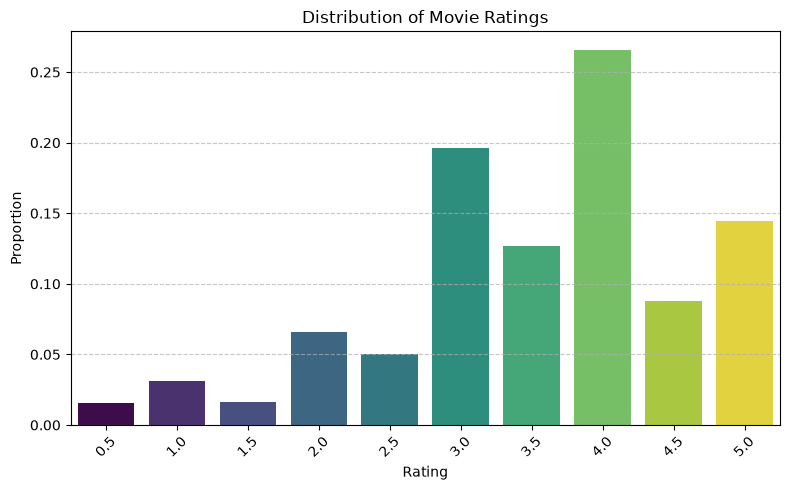

In [24]:
# Rating Distribution
print(movie_rating_df["rating"].value_counts(normalize=True, sort=True))

rating_distribution = movie_rating_df["rating"].value_counts(normalize=True).sort_index().reset_index()
rating_distribution.columns = ['rating', 'proportion']

plt.figure(figsize=(8, 5))
sns.barplot(x='rating', y='proportion', data=rating_distribution, palette='viridis', hue='rating', legend=False)
plt.title('Distribution of Movie Ratings')
plt.xlabel('Rating')
plt.ylabel('Proportion')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [25]:
print("mean rating: ", movie_rating_df["rating"].mean())
print("median rating: ", movie_rating_df["rating"].median())
print("most frequent rating: ", movie_rating_df["rating"].mode()[0])
print("min rating: ", movie_rating_df["rating"].min(), ",", "max rating: ", movie_rating_df["rating"].max())

mean rating:  3.533854451353085
median rating:  3.5
most frequent rating:  4.0
min rating:  0.5 , max rating:  5.0


title
Forrest Gump (1994)                          81491
Shawshank Redemption, The (1994)             81482
Pulp Fiction (1994)                          79672
Silence of the Lambs, The (1991)             74127
Matrix, The (1999)                           72674
Star Wars: Episode IV - A New Hope (1977)    68717
Jurassic Park (1993)                         64144
Schindler's List (1993)                      60411
Braveheart (1995)                            59184
Fight Club (1999)                            58773
Name: count, dtype: int64



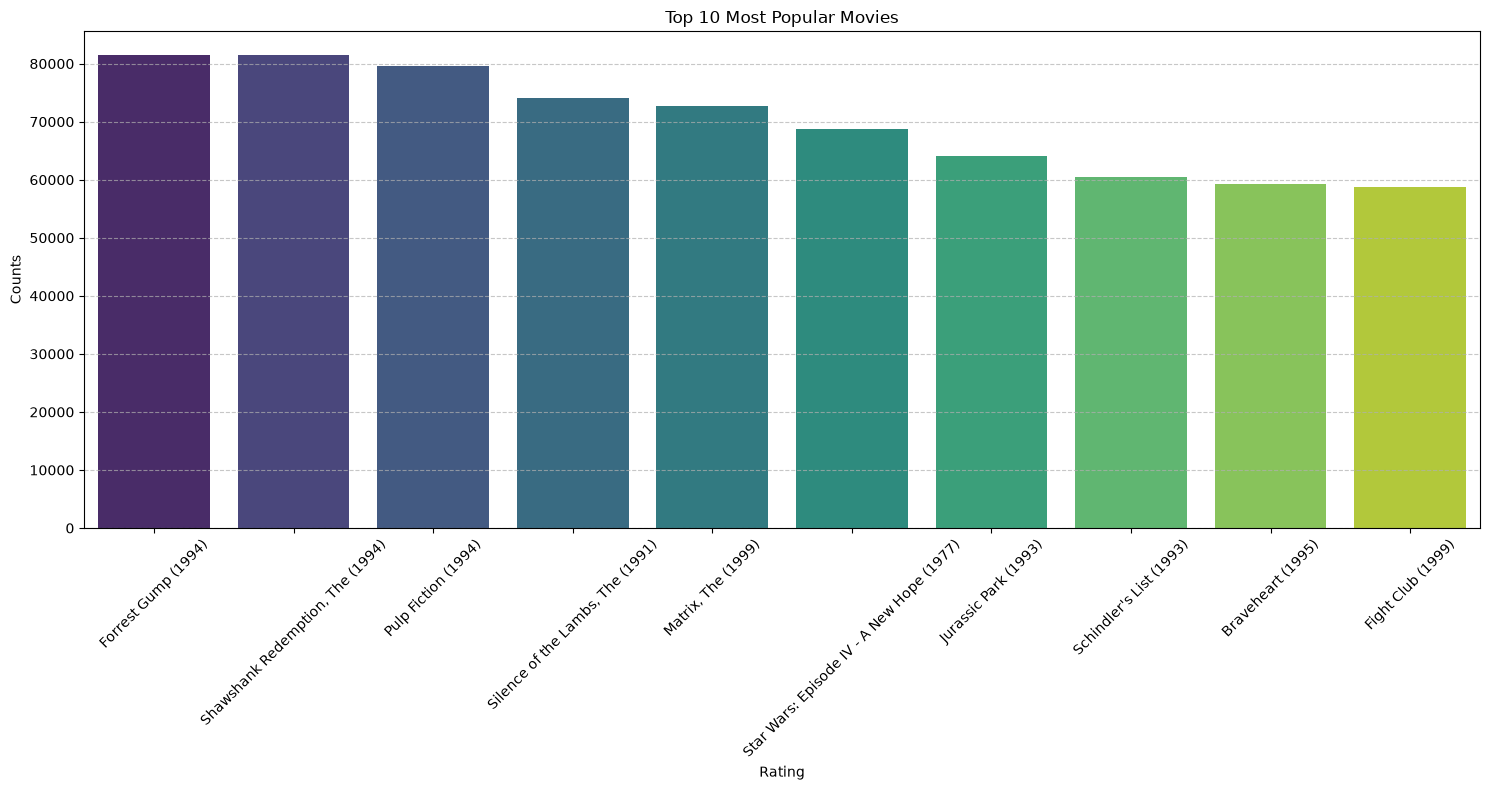

In [26]:
# Most Popular Movies
print(movie_rating_df["title"].value_counts().sort_values(ascending=False).head(10))
print()
top10_popular_movies = movie_rating_df["title"].value_counts().sort_values(ascending=False).head(10).reset_index()
top10_popular_movies.columns = ['title', 'counts']

plt.figure(figsize=(15, 8))
sns.barplot(x='title', y='counts', data=top10_popular_movies, palette='viridis', hue='title', legend=False)
plt.title('Top 10 Most Popular Movies')
plt.xlabel('Rating')
plt.ylabel('Counts')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [27]:
num_users = movie_rating_df["userid"].nunique()
num_movies = movie_rating_df["movieid"].nunique()
num_ratings = len(movie_rating_df)

possible_ratings = num_users * num_movies

density = num_ratings / possible_ratings
sparsity = 1 - density

print(f"Users: {num_users:,}")
print(f"Movies: {num_movies:,}")
print(f"Ratings: {num_ratings:,}")
print(f"Density: {density:.4%}")
print(f"Sparsity: {sparsity:.4%}")

Users: 162,541
Movies: 59,047
Ratings: 25,000,095
Density: 0.2605%
Sparsity: 99.7395%


In [28]:
user_rating_agg_df = movie_rating_df.groupby("userid").agg(
    min_rating = ("rating", "min"),
    max_rating = ("rating", "max"),
    num_ratings = ("rating", "count"),
    avg_rating = ("rating", "mean")
).reset_index()

print("avg no movies per user: ", user_rating_agg_df["num_ratings"].mean())
print()
user_rating_agg_df.head()

avg no movies per user:  153.80793153727367



,userid,min_rating,max_rating,num_ratings,avg_rating
0,1,0.5,5.0,70,3.814286
1,2,0.5,5.0,184,3.630435
2,3,2.0,5.0,656,3.697409
3,4,0.5,5.0,242,3.378099
4,5,2.0,5.0,101,3.752475


## Method 1) Rule Based Ranking - Popularity & Rating Quality

In [29]:
print(movie_rating_df.shape)
movie_rating_df.head(3)

(25000095, 5)


,userid,movieid,rating,title,genres
0,1,296,5.0,Pulp Fiction (1994),Comedy|Crime|Drama|Thriller
1,1,306,3.5,Three Colors: Red (Trois couleurs: Rouge) (1994),Drama
2,1,307,5.0,Three Colors: Blue (Trois couleurs: Bleu) (1993),Drama


In [30]:
unique_movie_rating = movie_rating_df.groupby("movieid").agg(
    title = ("title", "max"),
    avg_rating = ("rating", "mean"),
    no_ratings = ("rating", "count")
).reset_index()

print(unique_movie_rating.shape)
print()
unique_movie_rating.head(3)

(59047, 4)



,movieid,title,avg_rating,no_ratings
0,1,Toy Story (1995),3.893708,57309
1,2,Jumanji (1995),3.251527,24228
2,3,Grumpier Old Men (1995),3.142028,11804


In [31]:
# Perform test train split at each userid level

np.random.seed(42)
movie_rating_df['rand'] = np.random.rand(len(movie_rating_df))

# Sort by userid and then by the random number to get a random order within each group
movie_rating_df_sorted = movie_rating_df.sort_values(by=['userid', 'rand'])

# Calculate the cumulative count within each group (this will serve as a 'rank' for splitting)
movie_rating_df_sorted['rank_within_group'] = movie_rating_df_sorted.groupby('userid').cumcount() + 1
movie_rating_df_sorted['group_size'] = movie_rating_df_sorted.groupby('userid')['userid'].transform('count')

# Define the test ratio
test_ratio = 0.2

# Calculate the number of items for the test set for each group,
# For group_size > 1, calculate ceil(group_size * test_ratio). For group_size = 1, test_count should be 0.
movie_rating_df_sorted['calc_test_count'] = np.ceil(movie_rating_df_sorted['group_size'] * test_ratio).astype(int)
movie_rating_df_sorted['test_count_per_group'] = np.where(
    movie_rating_df_sorted['group_size'] > 1,
    movie_rating_df_sorted['calc_test_count'],
    0
)

# Condition for an item to be in the test set
is_in_test = (movie_rating_df_sorted['rank_within_group'] <= movie_rating_df_sorted['test_count_per_group'])

test_user_movie_df = movie_rating_df_sorted[is_in_test].drop(columns=['rand', 'rank_within_group', 'group_size', 'calc_test_count', 'test_count_per_group'])
train_user_movie_df = movie_rating_df_sorted[~is_in_test].drop(columns=['rand', 'rank_within_group', 'group_size', 'calc_test_count', 'test_count_per_group'])

print(f"Shape of training data: {train_user_movie_df.shape}")
print(f"Shape of testing data: {test_user_movie_df.shape}")
print(f"Ratio of Observations, Test to Input Df: {round(test_user_movie_df.shape[0] / (train_user_movie_df.shape[0] + test_user_movie_df.shape[0]), 2)}")

Shape of training data: (19936012, 5)
Shape of testing data: (5064083, 5)
Ratio of Observations, Test to Input Df: 0.2


In [33]:
# Display the first few rows of the training set
print("Train DataFrame:")
display(train_user_movie_df.head())

# Display the first few rows of the testing set
print("\nTest DataFrame:")
display(test_user_movie_df.head())

Train DataFrame:


,userid,movieid,rating,title,genres
31,1,5269,0.5,"Piano Teacher, The (La pianiste) (2001)",Drama
14,1,2068,2.5,Fanny and Alexander (Fanny och Alexander) (1982),Drama|Fantasy|Mystery
15,1,2161,3.5,"NeverEnding Story, The (1984)",Adventure|Children|Fantasy
49,1,7365,4.0,Noi the Albino (Nói albinói) (2003),Drama
57,1,8327,5.0,Dolls (2002),Drama|Romance



Test DataFrame:


,userid,movieid,rating,title,genres
10,1,1260,3.5,M (1931),Crime|Film-Noir|Thriller
42,1,6954,3.5,"Barbarian Invasions, The (Les invasions barbar...",Comedy|Crime|Drama|Mystery|Romance
58,1,8360,4.0,Shrek 2 (2004),Adventure|Animation|Children|Comedy|Musical|Ro...
29,1,4973,4.5,"Amelie (Fabuleux destin d'Amélie Poulain, Le) ...",Comedy|Romance
6,1,1175,3.5,Delicatessen (1991),Comedy|Drama|Romance


In [34]:
print(train_user_movie_df["userid"].nunique(), ",", test_user_movie_df["userid"].nunique())
print("This means all the users are in test and training set !")

162541 , 162541
This means all the users are in test and training set !


In [35]:
train_uniq_movie_df = train_user_movie_df.groupby("movieid").agg(
    title = ("title", "max"),
    avg_rating = ("rating", "mean"),
    no_ratings = ("rating", "count")
).reset_index()

print(train_uniq_movie_df.shape)
print()
train_uniq_movie_df.head()

(56649, 4)



,movieid,title,avg_rating,no_ratings
0,1,Toy Story (1995),3.892475,45473
1,2,Jumanji (1995),3.251781,19231
2,3,Grumpier Old Men (1995),3.147792,9422
3,4,Waiting to Exhale (1995),2.872208,2015
4,5,Father of the Bride Part II (1995),3.054067,9331


In [36]:
print("Distribution of Movie Ratings in Training Dataset\n")

print(train_uniq_movie_df["no_ratings"].describe(
    percentiles=[0.50, 0.75, 0.90, 0.95, 0.99]
))

Distribution of Movie Ratings in Training Dataset

count    56649.000000
mean       351.921693
std       2013.373644
min          1.000000
50%          5.000000
75%         33.000000
90%        357.000000
95%       1275.600000
99%       8192.080000
max      64819.000000
Name: no_ratings, dtype: float64


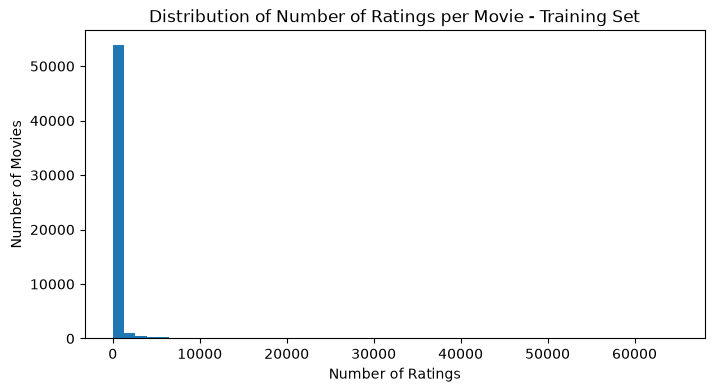

In [37]:
plt.figure(figsize=(8,4))
plt.hist(train_uniq_movie_df["no_ratings"], bins=50)
plt.xlabel("Number of Ratings")
plt.ylabel("Number of Movies")
plt.title("Distribution of Number of Ratings per Movie - Training Set")
plt.show()

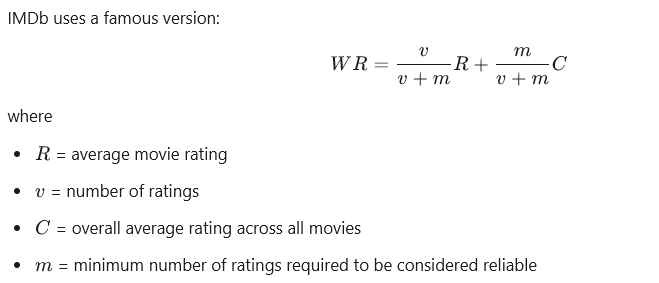

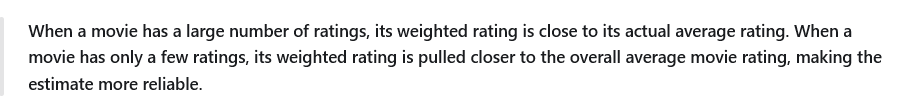

In [38]:
train_uniq_movie_df.head()

,movieid,title,avg_rating,no_ratings
0,1,Toy Story (1995),3.892475,45473
1,2,Jumanji (1995),3.251781,19231
2,3,Grumpier Old Men (1995),3.147792,9422
3,4,Waiting to Exhale (1995),2.872208,2015
4,5,Father of the Bride Part II (1995),3.054067,9331


In [39]:
min_no_ratings_reliable = 1500 #95% percentile rounded off to multiple of 100
ovr_mean_rating = train_uniq_movie_df["avg_rating"].mean()
print("Min no of ratings for reliability: ", min_no_ratings_reliable)
print("Overall mean rating across all movies: ", ovr_mean_rating)

train_uniq_movie_df["weighted_rating"] = (
    (train_uniq_movie_df["no_ratings"] / (train_uniq_movie_df["no_ratings"] + min_no_ratings_reliable)) * train_uniq_movie_df["avg_rating"]
    + (min_no_ratings_reliable / (train_uniq_movie_df["no_ratings"] + min_no_ratings_reliable)) * ovr_mean_rating
)

Min no of ratings for reliability:  1500
Overall mean rating across all movies:  3.0753846144461994


In [40]:
display(train_uniq_movie_df.loc[train_uniq_movie_df["no_ratings"] <= 10].head(3))
print()
display(train_uniq_movie_df.loc[train_uniq_movie_df["no_ratings"] >= 20000].head(3))

,movieid,title,avg_rating,no_ratings,weighted_rating
141,143,Gospa (1995),2.050000,10,3.068594
394,399,Girl in the Cadillac (1995),2.277778,9,3.070628
398,403,Two Crimes (Dos crímenes) (1995),2.150000,10,3.069256


,movieid,title,avg_rating,no_ratings,weighted_rating
0,1,Toy Story (1995),3.892475,45473,3.866382
9,10,GoldenEye (1995),3.419545,22466,3.398005
31,32,Twelve Monkeys (a.k.a. 12 Monkeys) (1995),3.908014,37424,3.875927


In [41]:
train_uniq_movie_df_pre_sorted = train_uniq_movie_df.sort_values(
  by='weighted_rating',
  ascending=False
)

watched_movies_by_user = (
    train_user_movie_df
    .groupby('userid')['movieid']
    .apply(set).
    to_dict()
)

In [42]:
#selection of top_n movies per user which are not in their training set i.e. recommend only the movie they haven't watched yet !
popular_movies = train_uniq_movie_df_pre_sorted.to_dict("records")

recommendations = []

for user_id, watched_movies in watched_movies_by_user.items():

    top_movies = []

    for movie in popular_movies:

        if movie["movieid"] in watched_movies:
            continue

        top_movies.append({
            "userid": user_id,
            "movieid": movie["movieid"],
            "title": movie["title"],
            "weighted_rating": movie["weighted_rating"]
        })

        if len(top_movies) == 10:
            break

    recommendations.extend(top_movies)

all_user_top_n_recommendations = pd.DataFrame(recommendations)

In [43]:
all_user_top_n_recommendations.loc[all_user_top_n_recommendations["userid"] == 2].reset_index(drop=True)

,userid,movieid,title,weighted_rating
0,2,318,"Shawshank Redemption, The (1994)",4.384051
1,2,50,"Usual Suspects, The (1995)",4.246032
2,2,1221,"Godfather: Part II, The (1974)",4.197628
3,2,2959,Fight Club (1999),4.192731
4,2,1193,One Flew Over the Cuckoo's Nest (1975),4.163428
5,2,296,Pulp Fiction (1994),4.162033
6,2,750,Dr. Strangelove or: How I Learned to Stop Worr...,4.145723
7,2,904,Rear Window (1954),4.140668
8,2,912,Casablanca (1942),4.137709
9,2,5618,Spirited Away (Sen to Chihiro no kamikakushi) ...,4.123821


In [44]:
all_user_top_n_recommendations.loc[all_user_top_n_recommendations["userid"] == 3].reset_index(drop=True)

,userid,movieid,title,weighted_rating
0,3,1221,"Godfather: Part II, The (1974)",4.197628
1,3,1193,One Flew Over the Cuckoo's Nest (1975),4.163428
2,3,750,Dr. Strangelove or: How I Learned to Stop Worr...,4.145723
3,3,904,Rear Window (1954),4.140668
4,3,2571,"Matrix, The (1999)",4.127722
5,3,5618,Spirited Away (Sen to Chihiro no kamikakushi) ...,4.123821
6,3,1203,12 Angry Men (1957),4.121308
7,3,1213,Goodfellas (1990),4.120089
8,3,2019,Seven Samurai (Shichinin no samurai) (1954),4.105138
9,3,1136,Monty Python and the Holy Grail (1975),4.094449


### Model Performance Evaluation

In [45]:
test_user_movie_df.loc[(test_user_movie_df["userid"] == 1) & (test_user_movie_df["rating"] >= 4)].head()

,userid,movieid,rating,title,genres
58,1,8360,4.0,Shrek 2 (2004),Adventure|Animation|Children|Comedy|Musical|Ro...
29,1,4973,4.5,"Amelie (Fabuleux destin d'Amélie Poulain, Le) ...",Comedy|Romance
56,1,8154,5.0,"Dolce Vita, La (1960)",Drama
37,1,6016,5.0,City of God (Cidade de Deus) (2002),Action|Adventure|Crime|Drama|Thriller
21,1,3448,4.0,"Good Morning, Vietnam (1987)",Comedy|Drama|War


In [46]:
test_user_movie_df.loc[(test_user_movie_df["userid"] == 3) & (test_user_movie_df["rating"] >= 4)].head()

,userid,movieid,rating,title,genres
821,3,106920,4.0,Her (2013),Drama|Romance|Sci-Fi
407,3,4963,4.0,Ocean's Eleven (2001),Crime|Thriller
456,3,5959,4.0,Narc (2002),Crime|Drama|Thriller
898,3,166528,4.0,Rogue One: A Star Wars Story (2016),Action|Adventure|Fantasy|Sci-Fi
563,3,33794,4.0,Batman Begins (2005),Action|Crime|IMAX


In [47]:
#DataPrep for Metrics Calculation
test_user_liked_movie_df = (
    test_user_movie_df.loc[
        test_user_movie_df["rating"] >= 4.0,
        ["userid", "movieid", "title"]
    ]
)

liked_movies_by_user = (
    test_user_liked_movie_df
    .groupby("userid")["movieid"]
    .apply(set)
    .to_dict()
)

recommendations_to_user = (
    all_user_top_n_recommendations
    .groupby("userid")["movieid"]
    .apply(list)
    .to_dict()
)

In [48]:
#PRECISION Calculation
precision_scores = []
k = 10

for userid in liked_movies_by_user:

    hits = len(
        liked_movies_by_user[userid] &
        set(recommendations_to_user[userid])
    )

    precision_scores.append(hits / k)

In [49]:
model_precision = np.mean(precision_scores)

print(f"Mean Precision@10    : {np.mean(precision_scores):.2%}")
print(f"Median Precision@10  : {np.median(precision_scores):.2%}")
print(f"25th Percentile      : {np.percentile(precision_scores, 25):.2%}")
print(f"75th Percentile      : {np.percentile(precision_scores, 75):.2%}")
print(f"Minimum Precision@10 : {np.min(precision_scores):.2%}")
print(f"Maximum Precision@10 : {np.max(precision_scores):.2%}")

Mean Precision@10    : 8.24%
Median Precision@10  : 0.00%
25th Percentile      : 0.00%
75th Percentile      : 10.00%
Minimum Precision@10 : 0.00%
Maximum Precision@10 : 100.00%


In [50]:
#RECALL Calculation
recall_scores = []

for userid in liked_movies_by_user:

    hits = len(
        liked_movies_by_user[userid] &
        set(recommendations_to_user[userid])
    )

    if liked_movies_by_user[userid]:
      recall_scores.append(hits / len(liked_movies_by_user[userid]))

In [51]:
model_recall = np.mean(recall_scores)
print(f"Model Recall: {model_recall:.2%}")
print("REcall is lesser than precision as avg user has ~16 liked movies in the test set, hence it is calculated at base 16")

Model Recall: 6.75%
REcall is lesser than precision as avg user has ~16 liked movies in the test set, hence it is calculated at base 16


In [52]:
print(f"Mean Recall@10    : {np.mean(recall_scores):.2%}")
print(f"Median Recall@10  : {np.median(recall_scores):.2%}")
print(f"25th Percentile      : {np.percentile(recall_scores, 25):.2%}")
print(f"75th Percentile      : {np.percentile(recall_scores, 75):.2%}")
print(f"Minimum Recall@10 : {np.min(recall_scores):.2%}")
print(f"Maximum Recall@10 : {np.max(recall_scores):.2%}")

Mean Recall@10    : 6.75%
Median Recall@10  : 0.00%
25th Percentile      : 0.00%
75th Percentile      : 9.09%
Minimum Recall@10 : 0.00%
Maximum Recall@10 : 100.00%


In [53]:
#NDCG Calculation

k=10
ndcg_scores = []

for userid in liked_movies_by_user.keys():

    relevant_movies = liked_movies_by_user[userid]
    recommended_movies = recommendations_to_user.get(userid, [])[:k]

    # --------- DCG ---------
    dcg = 0

    for rank, movieid in enumerate(recommended_movies, start=1):

        if movieid in relevant_movies:
            dcg += 1 / np.log2(rank + 1)

    # --------- IDCG ---------
    ideal_hits = min(len(relevant_movies), k)

    idcg = sum(
        1 / np.log2(rank + 1)
        for rank in range(1, ideal_hits + 1)
    )

    # --------- NDCG ---------
    if idcg > 0:
        ndcg_scores.append(dcg / idcg)

model_ndcg = np.mean(ndcg_scores)
print("Model %NDCG@10 :", model_ndcg * 100)
print("Higher NDCG than precision as it rewards earlier hits i.e. rank order of the recommended movies")

Model %NDCG@10 : 11.032188228264543
Higher NDCG than precision as it rewards earlier hits i.e. rank order of the recommended movies


In [54]:
evaluation_summary = pd.DataFrame({
    "Metric": [
        "NDCG@10",
        "Precision@10",
        "Recall@10",
        "Mean Relevant Movies/User",
        "Users Evaluated"
    ],
    "Value": [
        f"{model_ndcg:.2%}",
        f"{model_precision:.2%}",
        f"{model_recall:.2%}",
        round(test_user_liked_movie_df.groupby("userid")["movieid"].count().mean(), 2),
        f"{test_user_liked_movie_df['userid'].nunique():,}"
    ]
})

display(evaluation_summary)

,Metric,Value
0,NDCG@10,11.03%
1,Precision@10,8.24%
2,Recall@10,6.75%
3,Mean Relevant Movies/User,15.77
4,Users Evaluated,"160,259"


In [55]:
all_user_top_n_recommendations

,userid,movieid,title,weighted_rating
0,1,318,"Shawshank Redemption, The (1994)",4.384051
1,1,858,"Godfather, The (1972)",4.281711
2,1,50,"Usual Suspects, The (1995)",4.246032
3,1,527,Schindler's List (1993),4.210264
4,1,1221,"Godfather: Part II, The (1974)",4.197628
...,...,...,...,...
1625405,162541,912,Casablanca (1942),4.137709
1625406,162541,1203,12 Angry Men (1957),4.121308
1625407,162541,1213,Goodfellas (1990),4.120089
1625408,162541,79132,Inception (2010),4.108841


In [56]:
test_user_liked_movie_df.head()

,userid,movieid,title
58,1,8360,Shrek 2 (2004)
29,1,4973,"Amelie (Fabuleux destin d'Amélie Poulain, Le) ..."
56,1,8154,"Dolce Vita, La (1960)"
37,1,6016,City of God (Cidade de Deus) (2002)
21,1,3448,"Good Morning, Vietnam (1987)"
